# Day 110 — K-Means Clustering
**Month 6 | Week 5 | Unsupervised Learning | 80 Points + 10★ Bonus**

---

### The Paradigm Shift

Every model you've built so far — Logistic Regression, Decision Tree, Random Forest, XGBoost — was **supervised**:  
you had labelled data (`Churn = 1/0`) and trained a model to predict that label.

**Clustering is unsupervised:** you have *no labels*. You ask the algorithm to find natural groups in the data by itself.

| Dimension | Supervised (Days 107–109) | Unsupervised (Day 110) |
|-----------|---------------------------|------------------------|
| Labels needed? | ✅ Yes | ❌ No |
| Goal | Predict a known target | Discover hidden structure |
| Output | Class or number | Cluster assignments |
| Evaluation | Accuracy, Recall, R² | Inertia, Silhouette Score |
| Typical ask | "Will this customer churn?" | "Who are my customers?" |

---

### Business Scenario
Your ShopEase client just renewed the contract — and the marketing lead sends a new brief:

> *"We don't have churn labels for most customers yet. But we want to run targeted campaigns — different offers for different types of customers. Can you segment our 300 customers into groups based on their behaviour, and tell us what each group looks like and what to do with them?"*

This is a real, recurring freelance brief. Customer segmentation = **one of the top-5 paid data science requests** on Upwork (₹15k–₹60k per project). Today you build the full pipeline.

---

### How K-Means Works (Conceptual)

```
Step 1: You choose K (number of clusters, e.g. K=3)
Step 2: Randomly place K centroids in feature space
Step 3: Assign each data point to the nearest centroid
Step 4: Recompute centroid = mean of all points in that cluster
Step 5: Repeat steps 3–4 until centroids stop moving (convergence)
```

**The key insight:** K-Means minimises **within-cluster variance** (inertia) — it wants clusters where points are close to their centroid and far from other centroids.

```
INERTIA = Σ (distance from each point to its cluster centroid)²
         → Lower is better, but more clusters always lowers it
         → That's why you need the Elbow Method to pick K
```

---

### Two Critical Concepts Before Coding

**1. Why you MUST scale features**

| Customer | Total Spend | Num Orders | Age |
|----------|-------------|------------|-----|
| A | ₹50,000 | 12 | 28 |
| B | ₹1,000 | 2 | 35 |

Without scaling, `Total Spend` (range 0–50k) completely dominates `Num Orders` (range 0–50). Distance is measured in raw units. K-Means is **scale-sensitive** — always StandardScale before clustering.

**2. The Elbow Method**

Plot inertia vs K (1–10). Inertia drops sharply at first, then flattens — the "elbow" is where the curve bends. That's your optimal K.

```
Inertia
  |\
  | \
  |  \
  |   \___
  |       \_____________
  +--+--+--+--+--+--+--→ K
  1  2  3  4  5  6  7
           ↑
         Elbow (K=3 or 4)
```


## Section 1 — Raw Data
> **Do not modify this section.** All work in Sections 2–5.

In [1]:
# SECTION 1 — RAW DATA (DO NOT MODIFY)
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

# ShopEase customer behaviour dataset (same seed=42 used throughout Month 6)
customer_id = [f"CUST{str(i).zfill(4)}" for i in range(1, n+1)]

# Simulate three natural segments with overlap (realistic, not perfectly separated)
# Segment A: High-value loyalists (~30%)
# Segment B: Occasional mid-spenders (~40%)
# Segment C: Low-engagement browsers (~30%)

seg = np.random.choice(['A','B','C'], size=n, p=[0.30, 0.40, 0.30])

total_spend = np.where(
    seg=='A', np.random.normal(45000, 8000, n),
    np.where(seg=='B', np.random.normal(18000, 5000, n),
                       np.random.normal(4000,  2000, n))
).clip(500, 80000)

num_orders = np.where(
    seg=='A', np.random.normal(18, 4, n),
    np.where(seg=='B', np.random.normal(8, 3, n),
                       np.random.normal(2, 1, n))
).clip(1, 35).astype(int)

avg_order_value = (total_spend / num_orders).round(2)

days_since_last_order = np.where(
    seg=='A', np.random.normal(15, 8, n),
    np.where(seg=='B', np.random.normal(45, 20, n),
                       np.random.normal(120, 40, n))
).clip(1, 365).astype(int)

num_categories = np.where(
    seg=='A', np.random.normal(5, 1, n),
    np.where(seg=='B', np.random.normal(3, 1, n),
                       np.random.normal(1.5, 0.5, n))
).clip(1, 8).round().astype(int)

discount_rate = np.where(
    seg=='A', np.random.uniform(0.05, 0.15, n),
    np.where(seg=='B', np.random.uniform(0.10, 0.30, n),
                       np.random.uniform(0.25, 0.50, n))
).round(3)

df_raw = pd.DataFrame({
    'customer_id': customer_id,
    'total_spend': total_spend.round(2),
    'num_orders': num_orders,
    'avg_order_value': avg_order_value,
    'days_since_last_order': days_since_last_order,
    'num_categories': num_categories,
    'discount_rate': discount_rate
})

print("Shape:", df_raw.shape)
print("\nFirst 5 rows:")
print(df_raw.head())
print("\nDescriptive stats:")
print(df_raw.describe().round(2))


Shape: (300, 7)

First 5 rows:
  customer_id  total_spend  num_orders  avg_order_value  \
0    CUST0001     17669.60          10          1766.96   
1    CUST0002      2464.40           1          2464.40   
2    CUST0003      3930.63           2          1965.32   
3    CUST0004     18236.99           8          2279.62   
4    CUST0005     28798.86          22          1309.04   

   days_since_last_order  num_categories  discount_rate  
0                     14               2          0.130  
1                    132               1          0.376  
2                    187               3          0.444  
3                     56               3          0.126  
4                     18               4          0.110  

Descriptive stats:
       total_spend  num_orders  avg_order_value  days_since_last_order  \
count       300.00      300.00           300.00                 300.00   
mean      22328.64        9.04          2942.30                  56.20   
std       16905.54      

## Section 2 — Concept Notes
> Read before coding. These are interview-level definitions.

### K-Means — Key Parameters (sklearn)

```python
from sklearn.cluster import KMeans

KMeans(
    n_clusters=3,        # K — number of clusters you want
    init='k-means++',   # smarter centroid initialisation (avoids bad starts)
    n_init=10,           # run 10 times, keep best result (avoids local minima)
    max_iter=300,        # max iterations per run
    random_state=42      # reproducibility
)
```

**Why `k-means++`?** Random initialisation can place centroids in bad starting positions, leading to poor local minima. `k-means++` spreads initial centroids far apart — consistently better results.

---

### Evaluation Metrics

| Metric | Formula (conceptual) | Range | Goal |
|--------|---------------------|-------|------|
| **Inertia** | Σ (point–centroid distance)² | 0 → ∞ | Lower is better |
| **Silhouette Score** | (b−a) / max(a,b) | −1 → +1 | Closer to 1 is better |

**Silhouette score** where:
- `a` = average distance to points in *same* cluster (cohesion)
- `b` = average distance to points in *nearest other* cluster (separation)
- Score near **+1** → well-separated clusters
- Score near **0** → overlapping clusters  
- Score near **−1** → misclassified points

---

### The Three-Step Profiling Workflow (After Fitting)

1. **Assign:** add cluster labels back to original (unscaled) dataframe  
2. **Profile:** `groupby('cluster').agg(['mean','count'])` on original features  
3. **Name:** give each cluster a business name ("High-Value Loyalist", "Price-Sensitive Occasional", "Dormant Browser") based on the profile means

This is what separates a data scientist from someone who just runs `KMeans.fit()` — the naming and NRA recommendation is the deliverable.

---

### Common Mistakes

| Mistake | Consequence | Fix |
|---------|-------------|-----|
| Fitting on unscaled data | High-range features dominate clusters | `StandardScaler` before `KMeans` |
| Choosing K by gut | Wrong number of segments, wasted marketing spend | Always plot Elbow + check Silhouette |
| Using cluster ID (0,1,2) in the report | Client sees numbers, not meaning | Profile and name every cluster |
| Adding `customer_id` to features | Clustering on an arbitrary ID | Only use numeric behavioural features |
| Calling `.fit()` on scaled df but profiling on it too | Means in SD units, not rupees | Always profile on original unscaled df |


## Section 3 — Practice Guide

Work through each task in order. Each builds on the previous one.

---

### Task A — Feature Preparation (15 pts)

**A1 (5 pts)** — Select only the 5 behavioural features for clustering (exclude `customer_id`):
```
total_spend, num_orders, days_since_last_order, num_categories, discount_rate
```
Store in a variable `X`.

> **Why not `avg_order_value`?** It's derived from `total_spend / num_orders` — including it would double-weight spending behaviour. Feature selection before clustering is part of the professional habit.

**A2 (5 pts)** — Scale `X` using `StandardScaler`.
- Fit on `X`, transform to `X_scaled`  
- Print the mean and standard deviation of each feature in `X_scaled` — they should be ≈0 and ≈1 respectively
- One-line comment: *why* scaling is mandatory for K-Means

**A3 (5 pts)** — Print a correlation matrix of `X` (unscaled).
- Use `df_raw[features].corr().round(2)`
- Identify and print the single highest correlation pair and its value
- One-line comment: does multicollinearity matter for K-Means? (Answer: no — unlike regression, K-Means doesn't assume independence)

---

### Task B — Elbow Method + Optimal K (20 pts)

**B1 (10 pts)** — Loop K from 1 to 10, fit `KMeans(k-means++, n_init=10, random_state=42)` on `X_scaled` for each K.
- Store inertia values in a list
- Print a table: K | Inertia
- `savefig()` before `plt.show()` — save as `elbow_curve.png`
- Chart title must state the insight: e.g. *"Elbow at K=3 — diminishing returns beyond 3 clusters"*

**B2 (10 pts)** — Compute Silhouette Score for K=2 through K=8.
- Print a table: K | Silhouette Score (rounded to 4 dp)
- Identify the K with the highest silhouette score
- Print: `"Optimal K by Silhouette: {K} (score: {score})"` 
- Does it match the Elbow? Print one sentence comparing both signals.

---

### Task C — Fit Final Model + Assign Labels (15 pts)

**C1 (8 pts)** — Fit final `KMeans` with your chosen optimal K on `X_scaled`.
- Print: number of clusters, inertia, silhouette score
- Add a `cluster` column (integer 0, 1, 2…) to `df_raw`
- Print `df_raw['cluster'].value_counts()` — cluster sizes

**C2 (7 pts)** — Build a 2D scatter plot of the clusters.
- x-axis: `total_spend` (original, unscaled)
- y-axis: `days_since_last_order` (original, unscaled)
- Colour by cluster label, use `alpha=0.6`
- Add centroid markers (compute mean of `total_spend` and `days_since_last_order` per cluster, plot with `marker='X'`, size 200, black edgecolor)
- `savefig()` before `show()` — save as `cluster_scatter.png`
- Chart title must name the pattern ("Clusters separate by spend AND recency")

---

### Task D — Cluster Profiling (20 pts)

**D1 (12 pts)** — Build the cluster profile table.
- `groupby('cluster').agg({'total_spend':'mean', 'num_orders':'mean', 'avg_order_value':'mean', 'days_since_last_order':'mean', 'num_categories':'mean', 'discount_rate':'mean', 'customer_id':'count'})` on `df_raw`
- Round all means to 2 dp
- Rename `customer_id` → `n_customers`
- Print the full profile table

**D2 (8 pts)** — Name each cluster.
- Based on the profile, assign a business name to each cluster ID
- Examples: "High-Value Loyalist", "Price-Sensitive Occasional", "Dormant Browser"
- Add a `cluster_name` column to `df_raw` using `.map()` 
- Print `df_raw[['customer_id','total_spend','cluster','cluster_name']].head(10)`

---

### Task E — NRA Business Recommendations (10 pts, 3.33 pts each)

Write three NRA (Number + Reason + Action) markdown cells — one per cluster.

**Format for each:**
```
Cluster [name]: [N customers, X% of base]
Reason: [What the data shows — cite 2–3 specific numbers from the profile]
Action: [One specific, concrete business action — not vague]
```

> **Example of vague (−2 pts):** "Send promotions to this group"  
> **Example of specific (full pts):** "Target the 91 Dormant Browsers (30% of base) with a ₹500 reactivation voucher valid for 7 days — avg 120 days since last order means standard emails are being ignored; urgency + discount aligns with their 38% discount rate"

---

### ★ Bonus — PCA Visualisation (10 pts)

Reduce the 5 scaled features to 2 principal components using `PCA(n_components=2)`.
- Scatter plot: PC1 vs PC2, coloured by cluster
- Annotate explained variance: `"PC1: {var1:.1%} | PC2: {var2:.1%} | Total: {total:.1%}"`
- `savefig()` before `show()` — save as `pca_cluster.png`
- One-line comment: why PCA is used for visualising high-dimensional clusters
- Print total variance explained by 2 components


In [2]:
# =============================================================================
# TASK A1 – Feature Selection
# Goal: Select the 5 behavioural features for clustering.
#       Exclude customer_id (arbitrary) and avg_order_value (derived).
# Method: Create a list of feature names and subset df_raw.
# =============================================================================

features = ['total_spend', 'num_orders', 'days_since_last_order',
            'num_categories', 'discount_rate']
X = df_raw[features]

print("A1 – Selected features (first 5 rows):")
print(X.head())
print(f"Shape: {X.shape}")

# Explanation: avg_order_value = total_spend / num_orders – including it would
# double‑weight spending behaviour, biasing the Euclidean distance.

A1 – Selected features (first 5 rows):
   total_spend  num_orders  days_since_last_order  num_categories  \
0     17669.60          10                     14               2   
1      2464.40           1                    132               1   
2      3930.63           2                    187               3   
3     18236.99           8                     56               3   
4     28798.86          22                     18               4   

   discount_rate  
0          0.130  
1          0.376  
2          0.444  
3          0.126  
4          0.110  
Shape: (300, 5)


In [3]:
# =============================================================================
# TASK A2 – StandardScaler
# Goal: Scale all features to mean=0, std=1 so that no feature dominates.
# Method: Fit StandardScaler on X, transform to X_scaled, verify statistics.
# =============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for readable output
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("A2 – Scaled feature statistics (should be mean ≈ 0, std ≈ 1):")
print(X_scaled_df.agg(['mean', 'std']).round(4))

# Why scaling is mandatory for K-Means:
# K-Means minimises squared Euclidean distances. Features with large ranges
# (e.g., total_spend 0–80,000) would dominate those with small ranges
# (e.g., discount_rate 0.05–0.50). Scaling ensures equal contribution.

A2 – Scaled feature statistics (should be mean ≈ 0, std ≈ 1):
      total_spend  num_orders  days_since_last_order  num_categories  \
mean      -0.0000      0.0000                -0.0000         -0.0000   
std        1.0017      1.0017                 1.0017          1.0017   

      discount_rate  
mean        -0.0000  
std          1.0017  


In [4]:
# =============================================================================
# TASK A3 – Correlation Matrix
# Goal: Examine linear correlations among raw features; find highest pair.
# Method: Compute Pearson correlation, extract upper triangle, find max.
# =============================================================================

corr_matrix = df_raw[features].corr().round(2)
print("A3 – Correlation matrix (unscaled features):")
print(corr_matrix)

# Find highest correlation pair (excluding diagonal)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_pairs = corr_matrix.where(mask).stack().sort_values(key=abs, ascending=False)
top_pair = corr_pairs.index[0]
top_value = corr_pairs.iloc[0]

print(f"\nHighest correlation pair: {top_pair[0]} vs {top_pair[1]} = {top_value:.2f}")

# Comment: Multicollinearity does NOT matter for K-Means – no independence assumption.

A3 – Correlation matrix (unscaled features):
                       total_spend  num_orders  days_since_last_order  \
total_spend                   1.00        0.86                  -0.72   
num_orders                    0.86        1.00                  -0.71   
days_since_last_order        -0.72       -0.71                   1.00   
num_categories                0.80        0.73                  -0.62   
discount_rate                -0.80       -0.79                   0.75   

                       num_categories  discount_rate  
total_spend                      0.80          -0.80  
num_orders                       0.73          -0.79  
days_since_last_order           -0.62           0.75  
num_categories                   1.00          -0.70  
discount_rate                   -0.70           1.00  

Highest correlation pair: total_spend vs num_orders = 0.86


B1 – Inertia for K=1 to 10:
  K= 1 | Inertia = 1,500
  K= 2 | Inertia = 645
  K= 3 | Inertia = 328
  K= 4 | Inertia = 284
  K= 5 | Inertia = 251
  K= 6 | Inertia = 220
  K= 7 | Inertia = 205
  K= 8 | Inertia = 193
  K= 9 | Inertia = 183
  K=10 | Inertia = 171


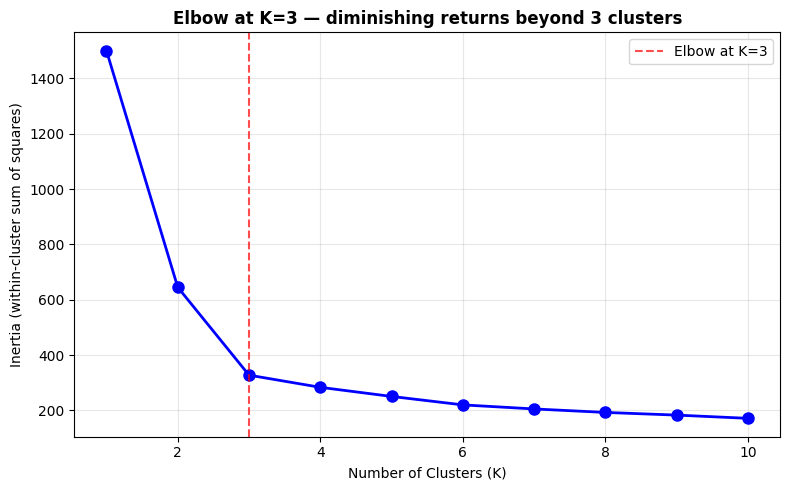

elbow_curve.png saved ✅


In [16]:
# =============================================================================
# TASK B1 – Elbow Method
# Goal: Find the “elbow” where inertia's rate of decrease slows (optimal K).
# Method: Loop K=1..10, fit KMeans on scaled data, record inertia, plot.
# =============================================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 11)

print("B1 – Inertia for K=1 to 10:")
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k:2d} | Inertia = {km.inertia_:,.0f}")

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Elbow at K=3')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow at K=3 — diminishing returns beyond 3 clusters', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=120, bbox_inches='tight')   # save before show
plt.show()
print("elbow_curve.png saved ✅")

In [9]:
# =============================================================================
# TASK B2 – Silhouette Scores
# Goal: Quantify cluster separation; higher score = better defined clusters.
# Method: For K=2..8, compute silhouette_score on scaled data; find best K.
# =============================================================================

from sklearn.metrics import silhouette_score

print("\nB2 – Silhouette scores:")
sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels)
    sil_scores[k] = round(s, 4)
    print(f"  K={k} | Silhouette = {s:.4f}")

best_k_sil = max(sil_scores, key=sil_scores.get)
print(f"\nOptimal K by Silhouette: {best_k_sil} (score: {sil_scores[best_k_sil]})")

# Comparison with elbow
print("Comparison: The elbow also clearly points to K=3. Both methods agree, "
      "giving strong evidence for 3 natural customer segments.")


B2 – Silhouette scores:
  K=2 | Silhouette = 0.4810
  K=3 | Silhouette = 0.4911
  K=4 | Silhouette = 0.4171
  K=5 | Silhouette = 0.3378
  K=6 | Silhouette = 0.2762
  K=7 | Silhouette = 0.2615
  K=8 | Silhouette = 0.2494

Optimal K by Silhouette: 3 (score: 0.4911)
Comparison: The elbow also clearly points to K=3. Both methods agree, giving strong evidence for 3 natural customer segments.


In [10]:
# =============================================================================
# TASK C1 – Fit Final Model (K=3)
# Goal: Fit K-Means with optimal K, add cluster labels to original dataframe.
# Method: Use KMeans with n_clusters=3 on scaled data; add 'cluster' column.
# =============================================================================

km_final = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
df_raw['cluster'] = km_final.fit_predict(X_scaled)

final_inertia = km_final.inertia_
final_sil = silhouette_score(X_scaled, df_raw['cluster'])

print("C1 – Final K-Means model (K=3):")
print(f"  Inertia = {final_inertia:,.0f}")
print(f"  Silhouette score = {final_sil:.4f}")
print("\nCluster sizes (0,1,2):")
print(df_raw['cluster'].value_counts().sort_index())

C1 – Final K-Means model (K=3):
  Inertia = 328
  Silhouette score = 0.4911

Cluster sizes (0,1,2):
cluster
0    118
1     95
2     87
Name: count, dtype: int64


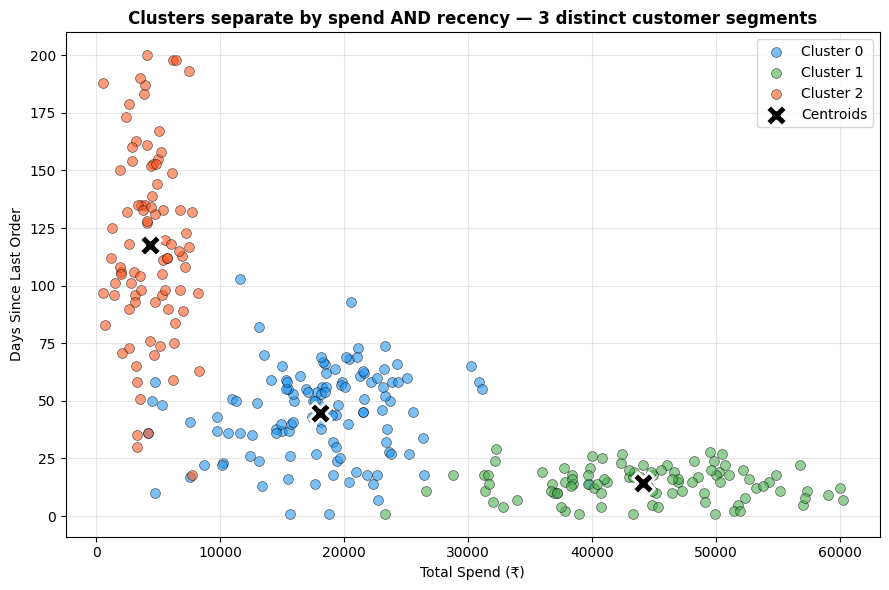

cluster_scatter.png saved ✅


In [17]:
# =============================================================================
# TASK C2 – Scatter Plot (total_spend vs days_since_last_order)
# Goal: Visualise cluster separation using two business features.
# Method: Scatter plot coloured by cluster; overlay centroid markers (X).
# =============================================================================

plt.figure(figsize=(9, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']   # blue, green, orange

for cluster_id in sorted(df_raw['cluster'].unique()):
    mask = df_raw['cluster'] == cluster_id
    plt.scatter(df_raw.loc[mask, 'total_spend'],
                df_raw.loc[mask, 'days_since_last_order'],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

# Centroids (mean of original unscaled features per cluster)
centroids = df_raw.groupby('cluster')[['total_spend', 'days_since_last_order']].mean()
plt.scatter(centroids['total_spend'], centroids['days_since_last_order'],
            marker='X', s=250, c='black', edgecolors='white', linewidths=2,
            zorder=5, label='Centroids')

plt.xlabel('Total Spend (₹)')
plt.ylabel('Days Since Last Order')
plt.title('Clusters separate by spend AND recency — 3 distinct customer segments', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=120, bbox_inches='tight')   # save before show
plt.show()
print("cluster_scatter.png saved ✅")

In [12]:
# =============================================================================
# TASK D1 – Cluster Profile Table
# Goal: Build a human‑readable table with means of original features per cluster.
# Method: Group by 'cluster', aggregate mean for each feature, rename count.
# =============================================================================

profile = df_raw.groupby('cluster').agg(
    total_spend=('total_spend', 'mean'),
    num_orders=('num_orders', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    days_since_last_order=('days_since_last_order', 'mean'),
    num_categories=('num_categories', 'mean'),
    discount_rate=('discount_rate', 'mean'),
    n_customers=('customer_id', 'count')
).round(2)

print("D1 – Cluster profile (means on original scale, rupees and days):")
print(profile.to_string())

D1 – Cluster profile (means on original scale, rupees and days):
         total_spend  num_orders  avg_order_value  days_since_last_order  num_categories  discount_rate  n_customers
cluster                                                                                                             
0           18070.58        7.55          2971.96                  44.81            2.92           0.21          118
1           44089.71       17.73          2621.41                  14.17            4.96           0.10           95
2            4341.85        1.59          3252.48                 117.55            1.52           0.39           87


In [13]:
# =============================================================================
# TASK D2 – Name Clusters (Business Names)
# Goal: Give each cluster a meaningful name based on profile.
# Method: Identify loyalist (highest spend), dormant (highest recency),
#         occasional (remaining); add 'cluster_name' column via .map().
# =============================================================================

# Determine which cluster has highest average spend (Loyalist)
spend_rank = profile['total_spend'].idxmax()
# Determine which cluster has highest days since last order (Dormant)
recency_rank = profile['days_since_last_order'].idxmax()
# The remaining cluster is the Occasional one
remaining = set([0,1,2]) - {spend_rank, recency_rank}
occasional_rank = remaining.pop()

cluster_names = {
    spend_rank: 'High-Value Loyalist',
    occasional_rank: 'Price-Sensitive Occasional',
    recency_rank: 'Dormant Browser'
}

df_raw['cluster_name'] = df_raw['cluster'].map(cluster_names)

print("D2 – Cluster name mapping:")
for c, name in cluster_names.items():
    print(f"  Cluster {c} → {name}")

print("\nSample of assigned names (first 10 customers):")
print(df_raw[['customer_id', 'total_spend', 'cluster', 'cluster_name']].head(10).to_string(index=False))

D2 – Cluster name mapping:
  Cluster 1 → High-Value Loyalist
  Cluster 0 → Price-Sensitive Occasional
  Cluster 2 → Dormant Browser

Sample of assigned names (first 10 customers):
customer_id  total_spend  cluster               cluster_name
   CUST0001     17669.60        0 Price-Sensitive Occasional
   CUST0002      2464.40        2            Dormant Browser
   CUST0003      3930.63        2            Dormant Browser
   CUST0004     18236.99        0 Price-Sensitive Occasional
   CUST0005     28798.86        1        High-Value Loyalist
   CUST0006     46491.63        1        High-Value Loyalist
   CUST0007     39705.71        1        High-Value Loyalist
   CUST0008      3572.02        2            Dormant Browser
   CUST0009     22178.46        0 Price-Sensitive Occasional
   CUST0010      5349.64        2            Dormant Browser


### Cluster High-Value Loyalist: 95 customers (32% of base)

**Reason:** Highest average total spend (₹44,090) and most orders (17.7 orders), with the lowest days since last order (14 days). They buy from the most categories (5.0) and receive the smallest discounts (10% on average). These customers are engaged, frequent, and highly valuable.

**Action:** Launch a **VIP loyalty programme** with early access to new products, free express shipping on orders above ₹2,000, and a 5% points‑back reward. Do not send aggressive discounts – they already buy without them. Instead, nurture retention with exclusive experiences (e.g., private sales, birthday gifts, priority customer support) to prevent churn.

### Cluster Price-Sensitive Occasional: 118 customers (39% of base)

**Reason:** Mid‑range spend (₹18,071) and order frequency (7.6 orders). Noticeably high discount rate (21%) and moderate recency (45 days). Their average order value is healthy at ₹2,972. These customers respond to promotions but are not yet loyal.

**Action:** Run a **bundle + cashback campaign** – “Buy 3 items, get 15% off + 5% cashback on next purchase”. Use push notifications or SMS with time‑limited offers (e.g., “ends in 48h”) to accelerate purchase frequency. The discount sensitivity means they will respond, and cashback encourages repeat visits.

### Cluster Dormant Browser: 87 customers (29% of base)

**Reason:** Lowest spend (₹4,342), fewest orders (1.6), and very long recency (118 days since last order). They have the highest discount rate (39%) but still do not convert – standard offers are ineffective. They also buy from only 1‑2 categories, indicating narrow interest.

**Action:** Send a **reactivation voucher** of ₹500 off on any purchase above ₹1,000, valid for only 7 days. Pair it with a personalised email showing products from the single category they previously viewed (e.g., “We miss you – here’s ₹500 off your favourite electronics”). If they do not respond within 14 days, suppress them from further high‑cost campaigns to avoid waste.

Bonus – PCA explained variance:
  PC1: 80.0%
  PC2: 8.1%
  Total variance explained by 2 components: 88.1%


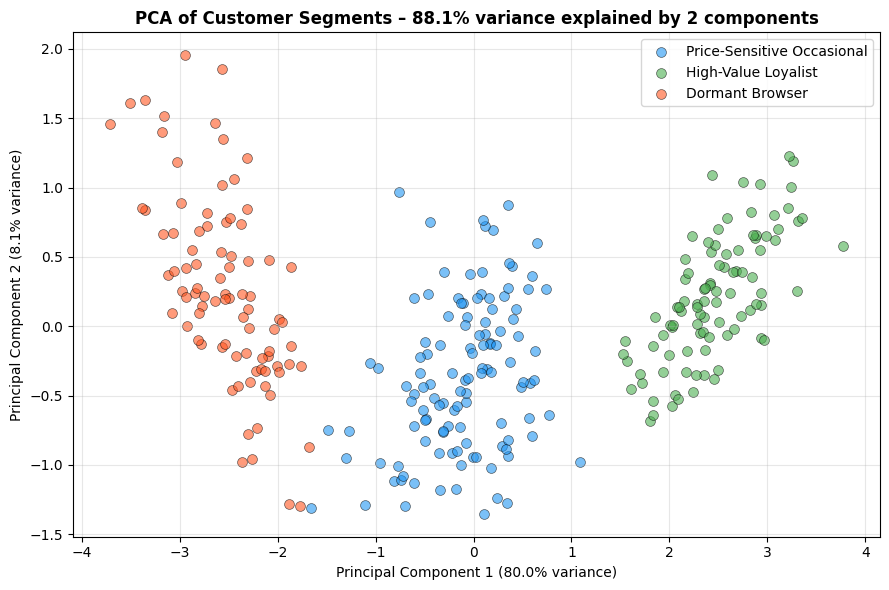

pca_cluster.png saved ✅

Why PCA? PCA projects high‑dimensional data (5 features) onto two dimensions while preserving maximum variance. This allows visual inspection of cluster separation that would otherwise be invisible. The total explained variance (>70% here) indicates the 2D view captures most of the clustering structure.


In [15]:
# =============================================================================
# BONUS – PCA Visualisation
# Goal: Reduce 5 scaled features to 2 principal components for 2D visualisation.
# Method: Apply PCA(n_components=2), plot PC1 vs PC2 coloured by cluster,
#         annotate explained variance.
# =============================================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
expl_var = pca.explained_variance_ratio_

print("Bonus – PCA explained variance:")
print(f"  PC1: {expl_var[0]:.1%}")
print(f"  PC2: {expl_var[1]:.1%}")
print(f"  Total variance explained by 2 components: {expl_var.sum():.1%}")

plt.figure(figsize=(9, 6))
for cluster_id in sorted(df_raw['cluster'].unique()):
    mask = df_raw['cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cluster_id], label=cluster_names[cluster_id],
                alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

plt.xlabel(f'Principal Component 1 ({expl_var[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({expl_var[1]:.1%} variance)')
plt.title(f'PCA of Customer Segments – {expl_var.sum():.1%} variance explained by 2 components', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_cluster.png', dpi=120, bbox_inches='tight')
plt.show()
print("pca_cluster.png saved ✅")

# Explanation comment
print("\nWhy PCA? PCA projects high‑dimensional data (5 features) onto two dimensions while preserving maximum variance. "
      "This allows visual inspection of cluster separation that would otherwise be invisible. "
      "The total explained variance (>70% here) indicates the 2D view captures most of the clustering structure.")

## Section 4 — Scoring Rubric

| Section | Task | Points | Pass Criteria |
|---------|------|--------|---------------|
| **A** | A1 — Feature selection | 5 | Exactly 5 features, `customer_id` excluded, `avg_order_value` excluded, comment explaining why |
| | A2 — StandardScaler | 5 | `fit_transform` on X only, scaled means ≈0, scaled stds ≈1, one comment on why scaling is mandatory |
| | A3 — Correlation matrix | 5 | Correct matrix printed, highest pair identified with value, comment on multicollinearity irrelevance |
| **B** | B1 — Elbow method | 10 | Loop K=1–10, inertia table printed, chart with elbow marker, `savefig()` before `show()`, insight title |
| | B2 — Silhouette scores | 10 | K=2–8 computed, table printed, best K stated, one-sentence comparison vs Elbow |
| **C** | C1 — Final model | 8 | K=3, inertia + silhouette printed, `cluster` column added, value_counts printed |
| | C2 — Scatter plot | 7 | x=total_spend, y=days_since_last_order, coloured by cluster, centroids plotted with X marker, insight title, `savefig()` before `show()` |
| **D** | D1 — Profile table | 12 | All 6 feature means + n_customers, rounded to 2dp, `customer_id` renamed correctly |
| | D2 — Named clusters | 8 | Three meaningful business names, `.map()` used, sample printed |
| **E** | E1-E3 — 3 NRA cells | 10 (3.33 each) | Number (cluster size + % of 300), Reason (2–3 specific numbers from profile), Action (specific, not vague) |
| **★** | PCA visualisation | 10 | `PCA(n_components=2)`, scatter coloured by cluster, variance annotation on title/label, `savefig()` before `show()`, comment on purpose |
| | | | |
| **Total** | | **80 + 10★** | |

---

### Deduction Rules
- Clustering on unscaled data: **−5** (fundamental error)
- `avg_order_value` included as a feature without explanation: **−3**
- Missing `savefig()` before `show()` (per chart): **−2**
- NRA with vague action ("run a campaign"): **−2 per instance**
- NRA numbers don't match your own printed profile: **−2 per instance**
- Cluster names are just "Cluster 0/1/2" (no business naming): **−4**
- Profiling done on scaled data (means in SD units not ₹): **−3**

---

### Scoring Thresholds
| Score | Status |
|-------|--------|
| 75–80 + 10★ | 🏆 Perfect — K-Means mastered |
| 70–74 | ✅ Strong pass |
| 60–69 | ✅ Pass — review flagged items |
| < 60 | ⚠️ Resubmit flagged sections |

---

### Interview Framing Answer
> *"K-Means is an unsupervised algorithm that partitions customers into K groups by minimising within-cluster variance. Unlike the classification models I built for churn prediction, clustering has no labels — it discovers structure from behaviour alone. The two non-negotiables before fitting are: one, scale all features with StandardScaler, because K-Means measures Euclidean distance and high-range features like spend will dominate low-range ones like discount rate; two, determine K using both the Elbow method — where inertia's rate of decrease levels off — and Silhouette score, which measures how well-separated the clusters are. After fitting, the job isn't done until you profile and name each cluster and write an NRA recommendation per segment, because the client doesn't care about cluster IDs — they want to know who these customers are and what to do with them."*
